In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta_img_front = '../../data/img/imagenMedicaFrontal.jpg'
ruta_img_lat = '../../data/img/imagenMedicaLateral.jpg'

image = cv2.imread(ruta_img_lat, cv2.IMREAD_GRAYSCALE)

TEST 1

In [31]:
gaussian_blur = cv2.GaussianBlur(image, (5, 5), 0)

In [32]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 25))

closed_image = cv2.morphologyEx(gaussian_blur, cv2.MORPH_CLOSE, kernel)

In [33]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))

black_tophat = cv2.morphologyEx(gaussian_blur, cv2.MORPH_BLACKHAT, kernel)

In [34]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
contrast_enhanced = clahe.apply(black_tophat)

In [37]:
gradient = cv2.morphologyEx(black_tophat, cv2.MORPH_GRADIENT, kernel)

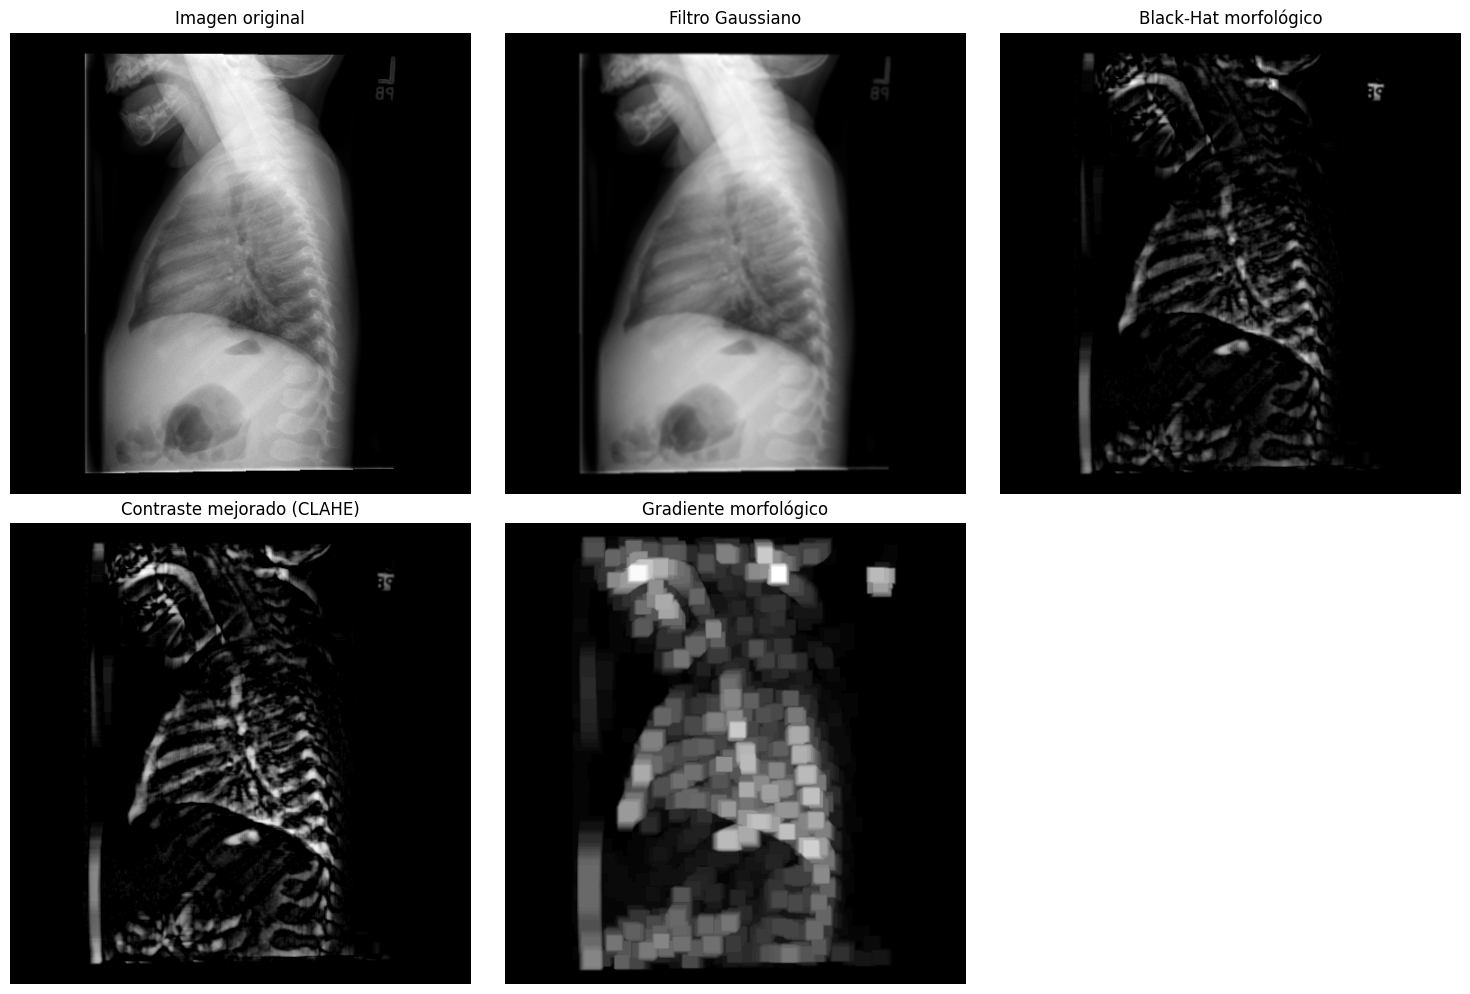

In [38]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.title("Imagen original")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Filtro Gaussiano")
plt.imshow(gaussian_blur, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Black-Hat morfológico")
plt.imshow(black_tophat, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Contraste mejorado (CLAHE)")
plt.imshow(contrast_enhanced, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Gradiente morfológico")
plt.imshow(gradient, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

TEST 2

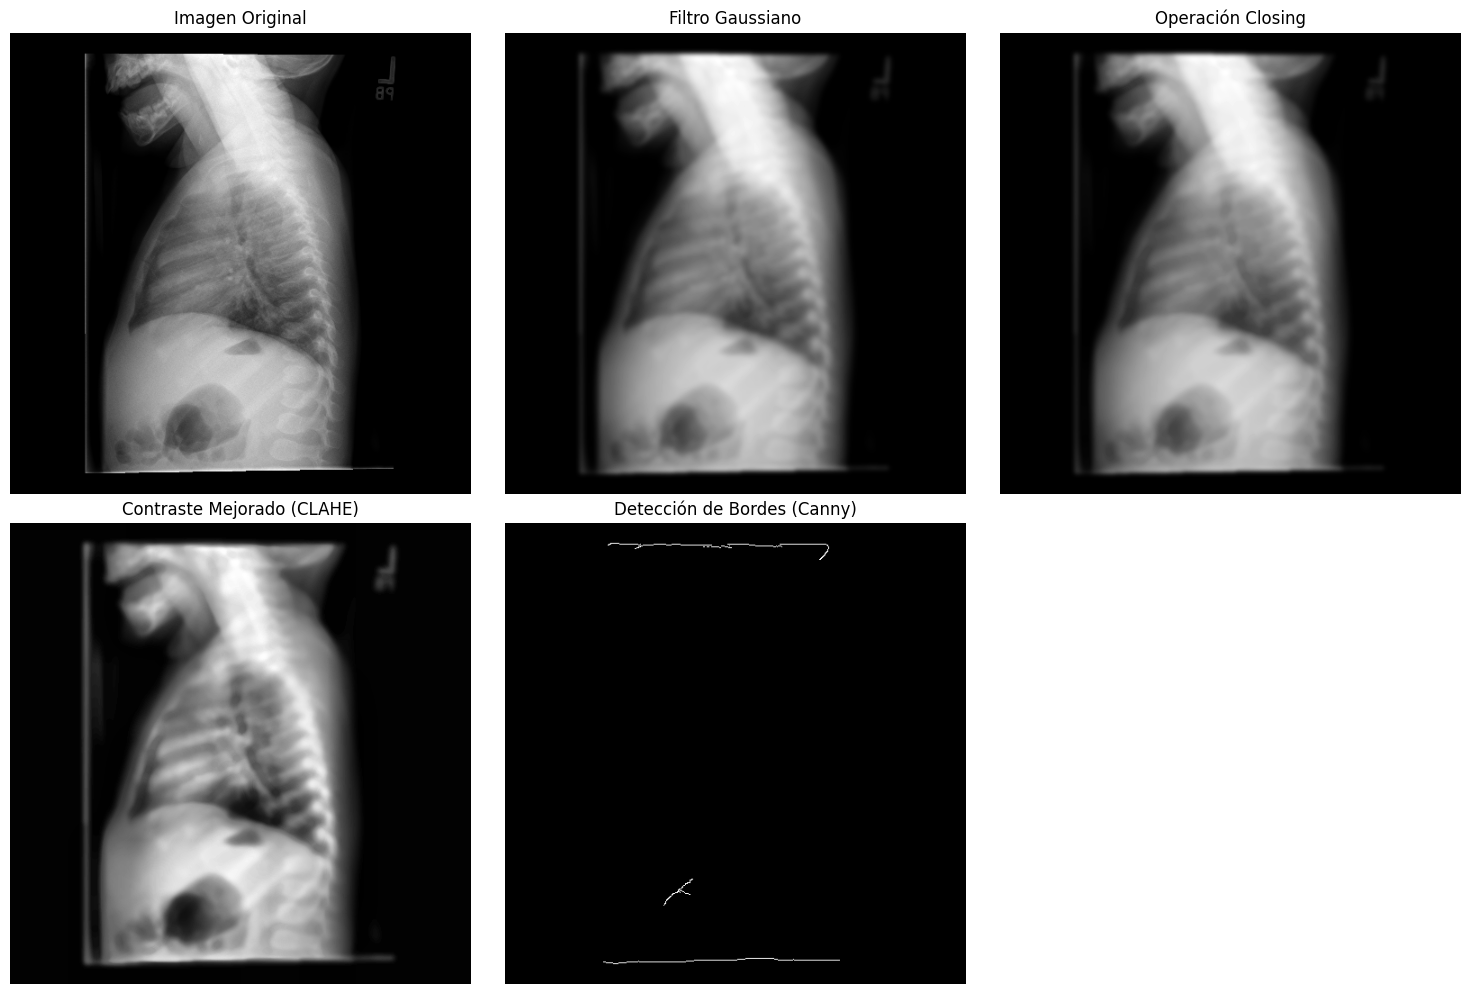

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta_img_lat = '../../data/img/imagenMedicaLateral.jpg' 

gaussian_blurred = cv2.GaussianBlur(image, (5, 5), 0)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

closing_image = cv2.morphologyEx(gaussian_blurred, cv2.MORPH_CLOSE, kernel)

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
contrast_enhanced = clahe.apply(closing_image)

edges = cv2.Canny(contrast_enhanced, threshold1=100, threshold2=200)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("Imagen Original")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Filtro Gaussiano")
plt.imshow(gaussian_blurred, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Operación Closing")
plt.imshow(closing_image, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Contraste Mejorado (CLAHE)")
plt.imshow(contrast_enhanced, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Detección de Bordes (Canny)")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()